In [138]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [139]:
import sys
import os
sys.path.append(os.path.abspath('/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation/src'))

from dgp import SpikedIsotropic
from utils import run_experiment, plot_experiment
from algorithms import SelfTrainedGradientDescent
from runner import TestEvaluatorCallback

import numpy as np
from scipy.special import logit

In [140]:
d = 500
p = 0.5
mu = np.zeros(d)
mu[0:5] = 0.5 
sigma = 1.0
seed = 42

data = SpikedIsotropic(d=d, mu=mu, sigma=sigma, p=p, seed=seed)

In [141]:
N = 100
M = 10000
N_test = 5000

X_lab, Y_lab, X_unl, Y_unl, X_test, Y_test = data.sample(N=N, M=M, N_test=N_test)

In [142]:
callback = TestEvaluatorCallback(X_lab, Y_lab, X_unl, Y_unl, X_test, Y_test)

T = 1000
T0 = 250
T1 = 300
kappa = logit(0.75)
lambda_ = 0.1
eta = 0.1
alpha = 0.5


st = SelfTrainedGradientDescent(
    n_iterations=T,  ramp_start=T0, ramp_end=T1, 
    margin_threshold=kappa, penalty_param=lambda_, 
    step_size=eta, pseudo_label_param=alpha,
    callback=callback
    )

In [143]:
st.fit(X_lab, Y_lab, X_unl)

/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation/src/algorithms.py:44: RuntimeWarning: divide by zero encountered in matmul
  scores_unl = X_unl_aug @ weights
/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation/src/algorithms.py:44: RuntimeWarning: overflow encountered in matmul
  scores_unl = X_unl_aug @ weights
/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation/src/algorithms.py:44: RuntimeWarning: invalid value encountered in matmul
  scores_unl = X_unl_aug @ weights


array([ 6.77870572e-02,  5.10385628e-01,  4.50044591e-01,  4.57940844e-01,
        4.48204576e-01,  4.24182969e-01, -3.60243548e-02, -5.08591645e-03,
        7.12027646e-02, -6.59648279e-03, -6.19966684e-02, -1.69477672e-02,
        2.89906790e-02,  9.63741100e-03, -1.81798464e-02, -8.04337264e-03,
        1.42948681e-02,  6.49712521e-02,  2.67352596e-02,  3.71035453e-02,
       -2.43799951e-02, -3.43965553e-03,  8.86627356e-02,  1.99344298e-02,
       -2.49488649e-02, -2.30542756e-03, -4.24010238e-02, -1.29681495e-02,
       -4.42832593e-02, -3.19965369e-02,  4.93696962e-02,  7.62473817e-02,
        4.54463267e-02, -3.09454945e-02, -1.45123598e-02,  3.32999861e-02,
        3.18011908e-02,  6.93039951e-02, -4.43777552e-02, -8.40060954e-03,
       -3.70308758e-02, -2.73735644e-03, -1.44633726e-02,  1.18992848e-01,
        1.49389615e-01, -6.88469248e-03, -4.42288699e-02,  1.81520873e-02,
        4.59853819e-02,  3.61136240e-02, -4.09065603e-02, -3.87957262e-02,
        6.70747982e-02, -

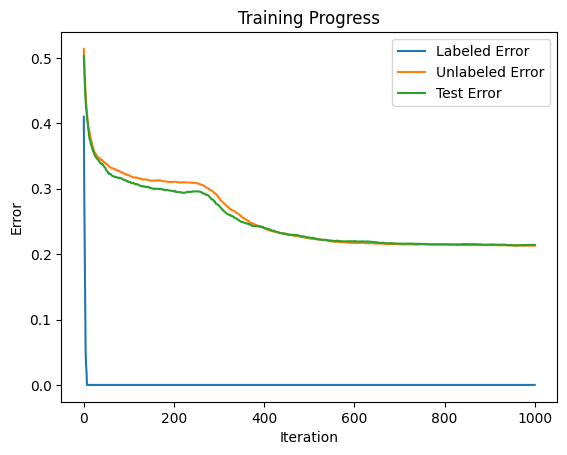

In [144]:
from matplotlib import pyplot as plt

plt.plot(callback.lab_error_history, label='Labeled Error')
plt.plot(callback.unl_error_history, label='Unlabeled Error')
plt.plot(callback.test_error_history, label='Test Error')

plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Training Progress')
plt.legend()
plt.show()

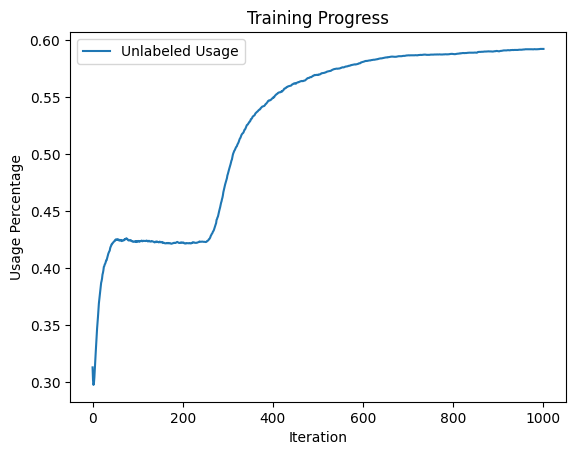

In [145]:
plt.plot(callback.unl_usage_history, label='Unlabeled Usage')

plt.xlabel('Iteration')
plt.ylabel('Usage Percentage')
plt.title('Training Progress')
plt.legend()
plt.show()

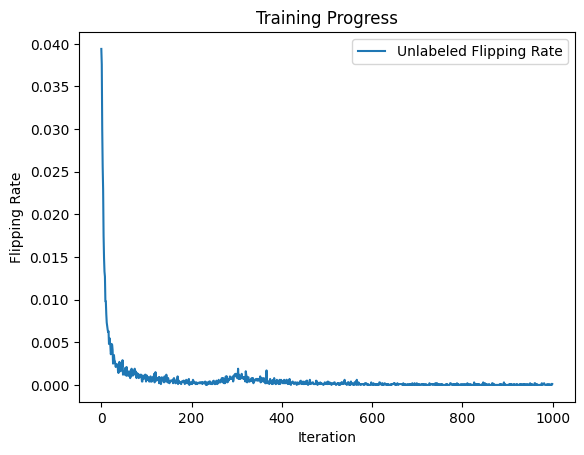

In [146]:
plt.plot(callback.unl_flipping_rate_history, label='Unlabeled Flipping Rate')

plt.xlabel('Iteration')
plt.ylabel('Flipping Rate')
plt.title('Training Progress')
plt.legend()
plt.show()